# Chapter 3 — Probability and Parameter Estimation

**Goals**

- Use Bayes' rule numerically.
- Sample from Bernoulli, Gaussian, and Multinomial distributions.
- Compute log-likelihoods.
- See MLE in action: estimate Gaussian parameters from a sample.
- Spot the connection between MLE and the loss function used in linear regression.

Pair with `docs/01_math_foundation.md` (Part B).

> The gradient portion lives in `notebooks/chapter_09_gradient_descent.ipynb`.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. Bayes' rule on the spam example

From `docs/01_math_foundation.md` §B.4: P(spam) = 0.01, P("lottery" | spam) = 0.80, P("lottery" | not-spam) = 0.01. What is P(spam | "lottery")?

In [2]:
p_spam            = 0.01
p_lottery_spam    = 0.80
p_lottery_notspam = 0.01

p_lottery = p_lottery_spam * p_spam + p_lottery_notspam * (1 - p_spam)
p_spam_given_lottery = (p_lottery_spam * p_spam) / p_lottery
print(f'P(lottery)              = {p_lottery:.4f}')
print(f'P(spam | lottery)       = {p_spam_given_lottery:.4f}')

P(lottery)              = 0.0179
P(spam | lottery)       = 0.4469


### Sweep the prior

Look at how the posterior depends on the prior. If you flip from "spam is 1%" to "spam is 50%", how much does P(spam | lottery) change?

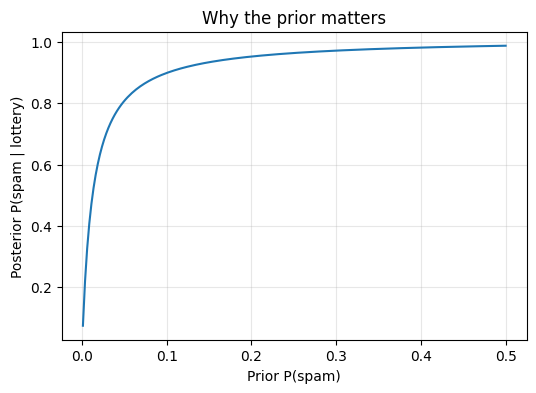

In [3]:
priors = np.linspace(0.001, 0.5, 200)
post = (p_lottery_spam * priors) / (p_lottery_spam * priors + p_lottery_notspam * (1 - priors))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(priors, post)
ax.set_xlabel('Prior P(spam)')
ax.set_ylabel('Posterior P(spam | lottery)')
ax.set_title('Why the prior matters')
ax.grid(True, alpha=0.3)
plt.show()

## 3. Three common distributions

Draw 10,000 samples from Bernoulli, Gaussian, and Multinomial. Verify the empirical mean matches theory.

In [4]:
n = 10_000
bern  = rng.binomial(n=1, p=0.3,   size=n)
gauss = rng.normal(loc=2.0, scale=1.5, size=n)
multi = rng.multinomial(n=1, pvals=[0.2, 0.5, 0.3], size=n).argmax(axis=1)

print(f'Bernoulli   empirical mean = {bern.mean():.3f}  (theory 0.300)')
print(f'Gaussian    empirical mean = {gauss.mean():.3f}  (theory 2.000)')
print(f'Gaussian    empirical std  = {gauss.std():.3f}  (theory 1.500)')
_, counts = np.unique(multi, return_counts=True)
print(f'Multinomial empirical pmf = {(counts / n).round(3)}  (theory [0.2, 0.5, 0.3])')

Bernoulli   empirical mean = 0.294  (theory 0.300)
Gaussian    empirical mean = 2.021  (theory 2.000)
Gaussian    empirical std  = 1.503  (theory 1.500)
Multinomial empirical pmf = [0.196 0.502 0.302]  (theory [0.2, 0.5, 0.3])


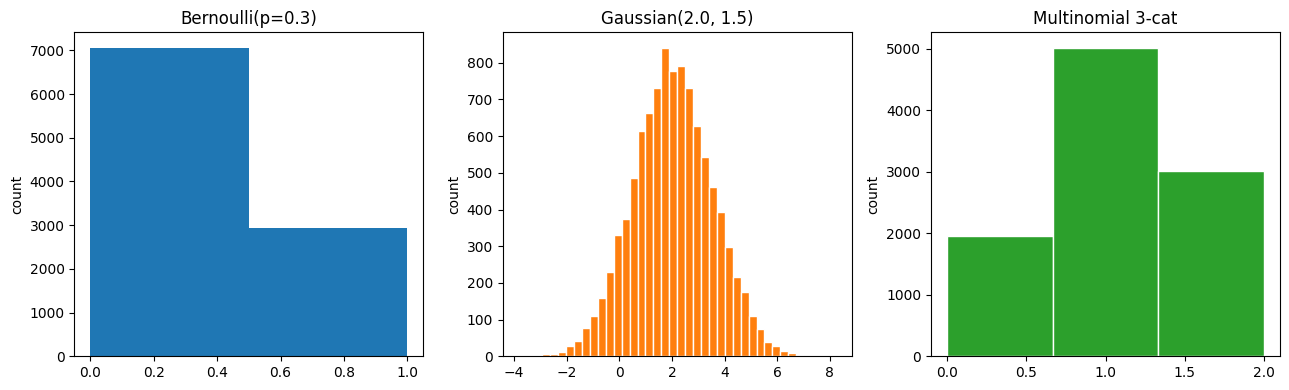

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(bern,  bins=2, color='tab:blue');  axes[0].set_title('Bernoulli(p=0.3)')
axes[1].hist(gauss, bins=40, color='tab:orange', edgecolor='white');  axes[1].set_title('Gaussian(2.0, 1.5)')
axes[2].hist(multi, bins=3, color='tab:green', edgecolor='white');    axes[2].set_title('Multinomial 3-cat')
for ax in axes:
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 4. Log-likelihood

Given Gaussian data, the log-likelihood as a function of $\mu$ (with $\sigma$ fixed) is a downward parabola. We will sweep $\mu$ and verify the peak sits at the sample mean.

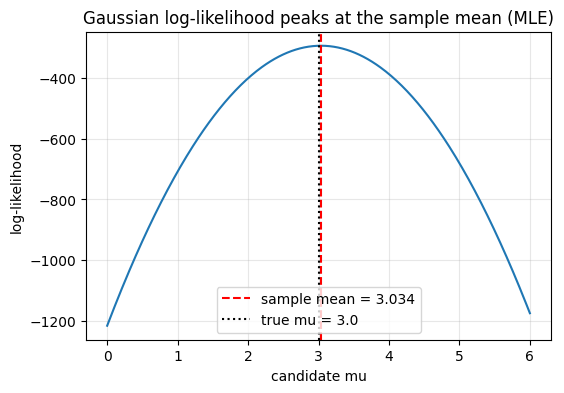

In [6]:
true_mu, true_sigma = 3.0, 1.0
x = rng.normal(true_mu, true_sigma, size=200)

def gaussian_log_likelihood(x, mu, sigma):
    return -0.5 * np.sum(((x - mu) / sigma) ** 2) - len(x) * np.log(sigma * np.sqrt(2 * np.pi))

mus = np.linspace(0, 6, 400)
lls = [gaussian_log_likelihood(x, mu, true_sigma) for mu in mus]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mus, lls)
ax.axvline(x.mean(), color='red', linestyle='--', label=f'sample mean = {x.mean():.3f}')
ax.axvline(true_mu,  color='black', linestyle=':', label=f'true mu = {true_mu}')
ax.set_xlabel('candidate mu')
ax.set_ylabel('log-likelihood')
ax.set_title('Gaussian log-likelihood peaks at the sample mean (MLE)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 5. MLE on Bernoulli — coin flips

Toss a biased coin 200 times. MLE for $p$ is just the fraction of heads.

In [7]:
true_p = 0.7
tosses = rng.binomial(n=1, p=true_p, size=200)
p_hat  = tosses.mean()
print(f'True p = {true_p}, MLE p_hat = {p_hat}')

# Closed form was a one-liner because dL/dp = 0 has the closed-form solution p = sum(x_i) / N.

True p = 0.7, MLE p_hat = 0.66


## 6. MLE = minimizing negative log-likelihood

Equivalent to a loss-minimization view: define $\mathcal{L}(\mu) = -\ell(\mu)$ and minimize.

minimum of -ll at mu = 3.0376  (sample mean = 3.0343)


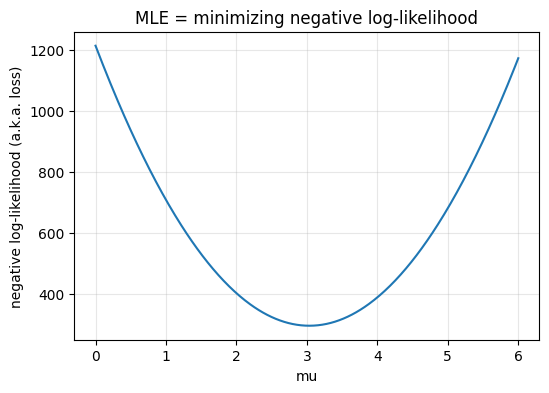

In [8]:
neg_lls = [-gaussian_log_likelihood(x, mu, true_sigma) for mu in mus]
best_mu = mus[int(np.argmin(neg_lls))]
print(f'minimum of -ll at mu = {best_mu:.4f}  (sample mean = {x.mean():.4f})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mus, neg_lls)
ax.set_xlabel('mu')
ax.set_ylabel('negative log-likelihood (a.k.a. loss)')
ax.set_title('MLE = minimizing negative log-likelihood')
ax.grid(True, alpha=0.3)
plt.show()

## 7. Summary

- Bayes' rule combines a prior and a likelihood into a posterior.
- The prior matters a lot when the base rate is small.
- MLE finds the parameter that maximizes the (log-)likelihood of the observed data.
- Loss minimization (e.g. MSE) is MLE under a Gaussian-noise assumption — they are the same thing.

**Next:** `notebooks/chapter_09_gradient_descent.ipynb` — how to actually find the optimum when there is no closed form.